New Order
- Train, val, test splitting sections 1-3
  - Hyperparameter tuning
    - https://www.youtube.com/watch?v=HgkiKRYc-3A
- Dataloader & Dataset section 4


## Setup

### Import Libraries

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import xarray as xr
import owncloud
from pathlib import Path
import pandas as pd

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split

### Utility Functions

In [139]:
def train(model: nn.Module, nepochs:int = 100, learning_rate: float = 0.001) -> None:

    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

    loss_function = nn.CrossEntropyLoss()

    losses = []
    accuracies = []
    for epoch in tqdm(range(nepochs)):


        optimizer.zero_grad()

        output = model.forward(features_train)

        loss = loss_function(output, labels_train)
        losses.append(loss.item())

        loss.backward()

        optimizer.step()

        accuracy = (labels_train == torch.argmax(output, dim=1)).sum()/len(labels_train)
        accuracies.append(accuracy)

def calculate_accuracy(model: nn.Module, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor: 

    output = model(features)

    accuracy = (labels == torch.argmax(output, dim=1)).sum()/len(labels)

    return accuracy

class utils:
    train = train
    calculate_accuracy = calculate_accuracy


In [ ]:
Path('data').mkdir(exist_ok=True, parents=True)

owncloud.Client.from_public_link('https://uni-bonn.sciebo.de/s/3Uf2gScrvuTPQhB').get_file('/', f'data/steinmetz_2017-01-08_Muller.nc')

True

In [3]:
dset = xr.load_dataset('data/steinmetz_2017-01-08_Muller.nc')
dset

<xarray.Dataset> Size: 124MB
Dimensions:             (trial: 261, time: 250, cell: 1268, sample: 82,
                         waveform_component: 3, probe: 384, brain_area_lfp: 5,
                         spike_id: 1836009)
Coordinates:
  * trial               (trial) int32 1kB 1 2 3 4 5 6 ... 257 258 259 260 261
  * time                (time) float64 2kB 0.01 0.02 0.03 0.04 ... 2.48 2.49 2.5
  * cell                (cell) int32 5kB 1 2 3 4 5 ... 1264 1265 1266 1267 1268
  * waveform_component  (waveform_component) int32 12B 1 2 3
  * probe               (probe) int32 2kB 1 2 3 4 5 6 ... 380 381 382 383 384
  * brain_area_lfp      (brain_area_lfp) <U5 100B 'CA1' 'DG' 'LP' 'PO' 'VISam'
  * spike_id            (spike_id) int32 7MB 1 2 3 4 ... 1836007 1836008 1836009
Dimensions without coordinates: sample
Data variables: (12/31)
    contrast_left       (trial) int8 261B 50 0 100 0 50 0 ... 100 0 100 0 100 0
    contrast_right      (trial) int8 261B 0 50 25 100 50 50 ... 100 50 100 25 25
    gocue               (trial) float64 2kB 0.9828 0.902 1.114 ... nan nan nan
    stim_onset          (trial) float64 2kB 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5
    feedback_type       (trial) float64 2kB 1.0 1.0 1.0 1.0 ... nan nan nan nan
    feedback_time       (trial) float64 2kB 1.272 1.104 1.402 ... nan nan nan
    ...                  ...
    waveform_w          (cell, sample, waveform_component) float32 1MB 0.0 .....
    waveform_u          (cell, waveform_component, probe) float32 6MB 0.0 ......
    lfp                 (brain_area_lfp, trial, time) float64 3MB -27.6 ... 0...
    spike_time          (spike_id) float32 7MB 2.363 2.385 ... 1.651 0.5142
    spike_cell          (spike_id) uint32 7MB 1 1 1 1 1 ... 1268 1268 1268 1268
    spike_trial         (spike_id) uint32 7MB 1 1 2 2 2 ... 205 205 205 213 252
Attributes:
    session_date:  2017-01-08
    mouse:         Muller
    stim_onset:    0.5
    bin_size:      0.01

Classification

In [4]:
spike_cols = ['spike_time', 'spike_cell', 'spike_trial']
contrast_cols = ['contrast_left', 'contrast_right']
df_spikes = dset[spike_cols].to_dataframe().reset_index()
df_contrast = dset[contrast_cols].to_dataframe().reset_index()

trial_ids = np.sort(df_spikes['spike_trial'].unique())


### Train a Classifier to Decode Stimulus Information from Spike Data

Make features out of spike data and labels for trials out of stimulus contrast

In [56]:

# classify trials based on which side had higher contrast
features_trials = []
labels_trials = []
for trial_id in trial_ids:
    trial_spikes = df_spikes[df_spikes['spike_trial'] == trial_id]
    
    # count spikes per cell, convert to firing rate
    spikes_per_cell = trial_spikes.groupby('spike_cell').size()
    feature_vector = np.zeros(1268)
    for cell_id, count in spikes_per_cell.items():
        feature_vector[cell_id - 1] = count  # cell_id starts at 1
    
    labels_trials.append(feature_vector)
    
    # Label: which side had higher contrast
    left = dset['contrast_left'].values[trial_id - 1]
    right = dset['contrast_right'].values[trial_id - 1]

    if left > right:
        labels_trials.append(0)
    elif right > left:
        labels_trials.append(1)
    else:
        labels_trials.append(2)

#labels = np.array(features_trials)
#labels = np.array(labels_trials)

Make features and labels tensors and create dataset

In [94]:
features = torch.tensor(np.array(features_trials), dtype=torch.float64)
labels = torch.tensor(np.array(labels_trials), dtype=torch.long)

## Section 1: Split Data into Train, Validation, and Test Data.

| Code | Description |
|---|---|
| `features_train, features_val, features_test = random_split(features, lengths = [fractionA, fractionB, fractionC])` | Splits the data in `features` tensor into subsets. The fractions in `lengths` specifies the proportion of the data that should go into each subset. |
| `torch.Generator().manual_seed(some_num)` | Sets the seed. |
| `features_train, features_val, features_test = random_split(features, lengths = [fractionA, fractionB, fractionC], generator=some_torch_generator)` | The parameter `generator` can be fixed to make sure that the data is split in exactly the same way each time. This ensures reproducibility. |

#### **Exercises**

**Example**: Split the dataset into only two subsets: a train and a test subset. Set the fraction of the data going into the train dataset to 0.8 and the fraction going into test subset to 0.2.

In [95]:
train_fraction = 0.8
test_fraction = 0.2

features_train, features_test = random_split(features, lengths=[train_fraction, test_fraction])

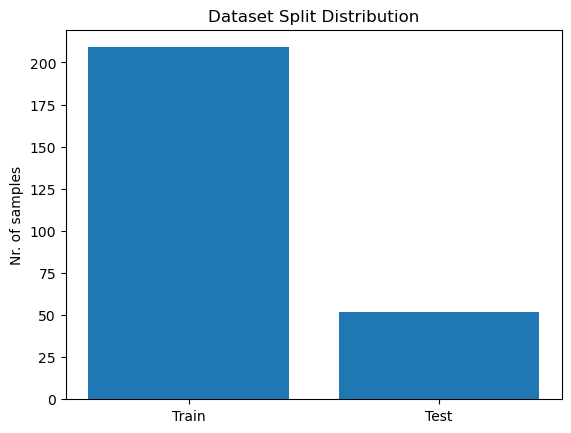

In [96]:
plt.bar(['Train', 'Test'], [len(features_train), len(features_test)])
plt.ylabel("Nr. of samples")
plt.title('Dataset Split Distribution');

**Exercise**: Split the features tensor into three subsets according to the fractions provided below. One subset is used for training the model, one for validation during training - i.e. to train hyperparameters, and the last subset is used to test the final model.

In [97]:
train_fraction = 0.7
val_fraction = 0.15
test_fraction = 1-train_fraction-val_fraction

In [98]:
features_train, features_val, features_test = random_split(features, lengths=[train_fraction, val_fraction, test_fraction])

Text(0.5, 1.0, 'Dataset Split Distribution')

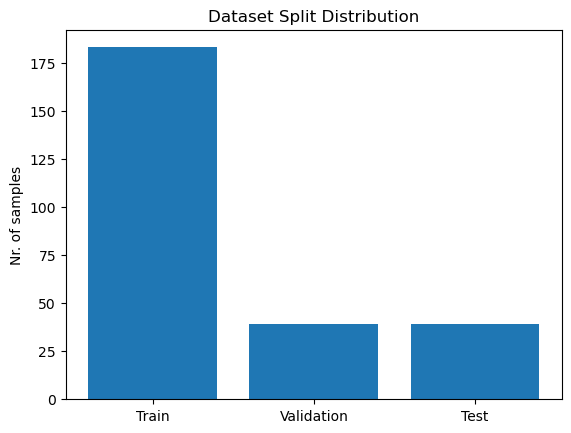

In [99]:
plt.bar(['Train', 'Validation', 'Test'], [len(features_train), len(features_val), len(features_test)])
plt.ylabel("Nr. of samples")
plt.title('Dataset Split Distribution')

**Exercise**: Set the fraction of the data going into the train dataset to `0.8` and the fractions going into the validation and test subsets to `0.1`. Then, split the features tensor again and run the cell plotting the number of samples in each subdataset.

In [100]:
train_fraction = 0.8
val_fraction = 0.1
test_fraction = 1-train_fraction-val_fraction

features_train, features_val, features_test = random_split(features, lengths=[train_fraction, val_fraction, test_fraction])

Text(0.5, 1.0, 'Dataset Split Distribution')

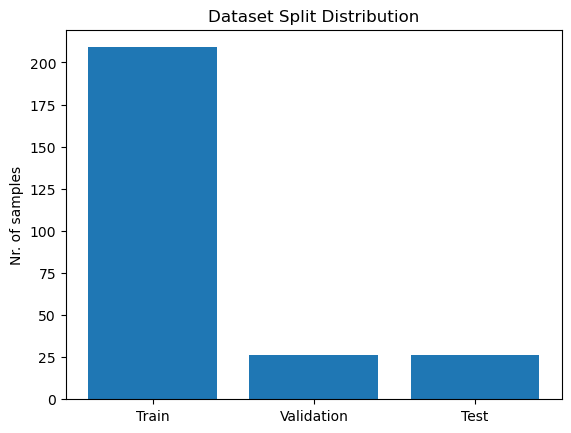

In [101]:
plt.bar(['Train', 'Validation', 'Test'], [len(features_train), len(features_val), len(features_test)])
plt.ylabel("Nr. of samples")
plt.title('Dataset Split Distribution')

**Exercise**: Split the **labels** tensor into three subsets according to the fractions provided below. One subset is used for training the model, one for validation during training - i.e. to train hyperparameters, and the last subset is used to test the final model.

In [102]:
train_fraction = 0.7
val_fraction = 0.15
test_fraction = 1-train_fraction-val_fraction

In [103]:
labels_train, labels_val, labels_test = random_split(labels, lengths=[train_fraction, val_fraction, test_fraction])

Text(0.5, 1.0, 'Dataset Split Distribution')

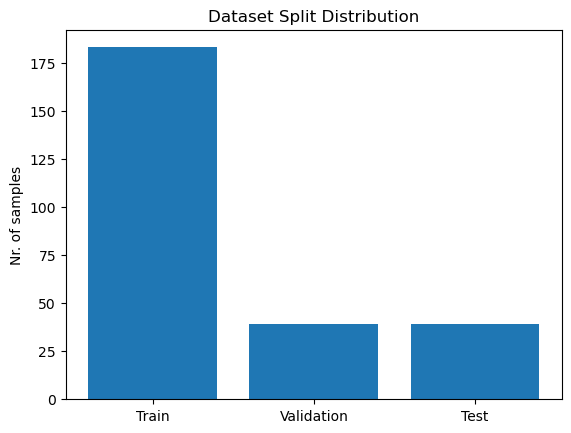

In [104]:
plt.bar(['Train', 'Validation', 'Test'], [len(labels_train), len(labels_val), len(labels_test)])
plt.ylabel("Nr. of samples")
plt.title('Dataset Split Distribution')

As the name suggests, the `random_split` function splits the data randomly each time it's run. This means that even though the proportions are the same, you'll have different samples in the train, validation, and test subsets each time you run the code to split the data. To ensure reproducibility - that you get the same result each time you train the model on your data, you have to provide a random number generator with a fixed seed to the function.

**Exercise**: In the cell below, the data is split without providing a generator. Run the code in the cell below where features and a label fetched from the training subset is displayed after splitting. Do you get the same or different values when you run the code repeatedly?

In [105]:
train_fraction = 0.7
val_fraction = 0.15
test_fraction = 1-train_fraction-val_fraction

features_train, features_val, features_test = random_split(features, lengths=[train_fraction, val_fraction, test_fraction])
labels_train, labels_val, labels_test = random_split(labels, lengths=[train_fraction, val_fraction, test_fraction])

features_train[0], labels_train[0]

(tensor([ 0.,  4., 11.,  ...,  5.,  1.,  0.], dtype=torch.float64), tensor(0))

**Exercise**: Create a PyTorch Pseudorandom Number Generator from the seed below.

In [106]:
SEED = 42

In [107]:
SEED = 42
generator = torch.Generator().manual_seed(SEED)
generator

**Exercise**: Create a PyTorch Generator from the seed below. Then, run the cell below where the data is split with the generator passed to the `random_split` function. Do you get the same or different values when you run the code repeatedly?

In [108]:
SEED = 2026

In [109]:
generator = torch.Generator().manual_seed(SEED)

train_fraction = 0.7
val_fraction = 0.15
test_fraction = 1-train_fraction-val_fraction

features_train, features_val, features_test = random_split(features, lengths=[train_fraction, val_fraction, test_fraction], generator=generator)
labels_train, labels_val, labels_test = random_split(labels, lengths=[train_fraction, val_fraction, test_fraction], generator=generator)

features_train[0], labels_train[0]

(tensor([ 0.,  9., 14.,  ...,  0.,  1.,  0.], dtype=torch.float64), tensor(2))

## Section 2: Tune Hyperparameters on Validation Dataset

In [136]:
SEED = 2026
generator = torch.Generator().manual_seed(SEED)

train_fraction = 0.7
val_fraction = 0.15
test_fraction = 1-train_fraction-val_fraction

features_train, features_val, features_test = random_split(features, lengths=[train_fraction, val_fraction, test_fraction], generator=generator)
labels_train, labels_val, labels_test = random_split(labels, lengths=[train_fraction, val_fraction, test_fraction], generator=generator)

features_train, features_val, features_test = features_train.dataset.float(), features_val.dataset.float(), features_test.dataset.float()
labels_train, labels_val, labels_test = labels_train.dataset, labels_val.dataset, labels_test.dataset

**Example**: 

In [137]:
n_cells = 1268
n_classes = 3

# define model with two fully connected layers and one ReLU layer between them
class Model(nn.Module):
    def __init__(self, hidden_layer_size = 32):
        super().__init__()

        self.fc1 = nn.Linear(n_cells, hidden_layer_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_layer_size, n_classes)

    def forward(self, x):
        out1 = self.fc1(x)
        out2 = self.relu(out1)
        return self.fc2(out2)


In [140]:
hidden_layer_sizes = [12, 64, 128]
for hidden_layer_size in hidden_layer_sizes:

    # create model
    model = Model(hidden_layer_size=hidden_layer_size)

    # rain the model
    utils.train(model)

100%|██████████| 100/100 [00:00<00:00, 207.70it/s]


In [141]:
# Calculate validation accuracy
accuracy_val = utils.calculate_accuracy(model, features_val, labels_val)
print(f'Validation Accuracy: {accuracy_val:.4f}')

Validation Accuracy: 0.9808


In [123]:
hidden_sizes = [12, 64, 128]
val_accuracies = []

for hidden_size in hidden_sizes:
    print(f'\nTraining with hidden size: {hidden_size}')
    
    # Create model
    model = nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, n_classes)
    )
    
    # Train
    utils.train(model, features_train.float(), labels_train, nepochs=10)
    
    # Evaluate on validation
    val_acc = utils.calculate_accuracy(model, features_val.float(), labels_val)
    val_accuracies.append(val_acc.item())
    print(f'Validation Accuracy: {val_acc:.4f}')


Training with hidden size: 12


100%|██████████| 10/10 [00:00<00:00, 165.91it/s]


Validation Accuracy: 0.3295

Training with hidden size: 64


100%|██████████| 10/10 [00:00<00:00, 239.83it/s]


Validation Accuracy: 0.6207

Training with hidden size: 128


100%|██████████| 10/10 [00:00<00:00, 165.72it/s]

Validation Accuracy: 0.3755


(0.0, 1.0)

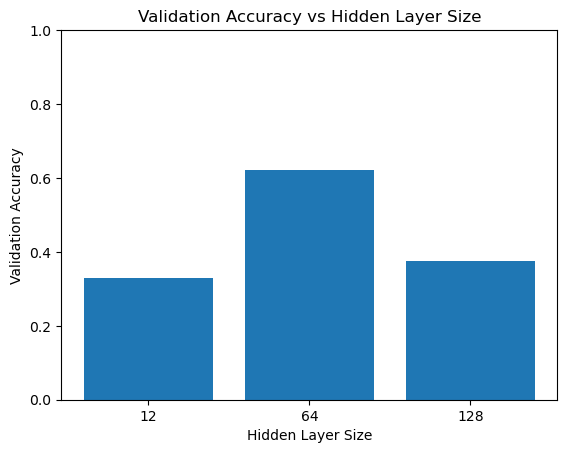

In [124]:
# Plot results
plt.bar([str(h) for h in hidden_sizes], val_accuracies)
plt.xlabel('Hidden Layer Size')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs Hidden Layer Size')
plt.ylim([0, 1])

In [127]:
epoch_counts = [5, 50, 100]
val_accuracies = []

for n_epochs in epoch_counts:
    print(f'\nTraining for {n_epochs} epochs')
    
    # Create model
    model = nn.Sequential(
        nn.Linear(input_size, 64),
        nn.ReLU(),
        nn.Linear(64, n_classes)
    )
    
    # Train
    utils.train(model, features_train.float(), labels_train, nepochs=n_epochs)
    
    # Evaluate on validation
    val_acc = utils.calculate_accuracy(model, features_val.float(), labels_val)
    val_accuracies.append(val_acc.item())
    print(f'Validation Accuracy: {val_acc:.4f}')


Training for 5 epochs


100%|██████████| 5/5 [00:00<00:00, 93.64it/s]


Validation Accuracy: 0.4943

Training for 50 epochs


100%|██████████| 50/50 [00:00<00:00, 173.49it/s]


Validation Accuracy: 0.7931

Training for 100 epochs


100%|██████████| 100/100 [00:00<00:00, 212.17it/s]

Validation Accuracy: 0.9847


(0.0, 1.0)

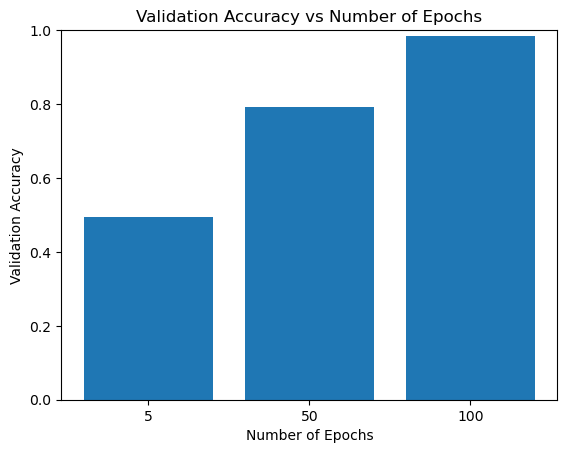

In [128]:
# Plot results
plt.bar([str(e) for e in epoch_counts], val_accuracies)
plt.xlabel('Number of Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs Number of Epochs')
plt.ylim([0, 1])

In [ ]:
# Use best hyperparameters found from validation
best_hidden_size = 64  # Replace with your best value
best_n_epochs = 10     # Replace with your best value

print(f'Training final model with:')
print(f'  Hidden size: {best_hidden_size}')
print(f'  Epochs: {best_n_epochs}')

# Train final model
final_model = nn.Sequential(
    nn.Linear(input_size, best_hidden_size),
    nn.ReLU(),
    nn.Linear(best_hidden_size, n_classes)
)

utils.train(final_model, features_train.float(), labels_train, nepochs=best_n_epochs)

# Evaluate on test data (only once!)
test_accuracy = utils.calculate_accuracy(final_model, features_test.float(), labels_test)
print(f'Final Test Accuracy: {test_accuracy:.4f}')

## Section 3: Do Split Sizes Matter?

## Section 4: Batching Data to Train Efficiently

If your dataset is large, you might run out of memory during training. 

| Code | Description |
|---|---|
| `DataLoader(dataset)` | Create a DataLoader for `dataset` and assign it to the variable `dataloader`. |
| `DataLoader(dataset, batch_size = some_num)` | Create a DataLoader for `dataset` where the size of each batch set to `some_num` (default batchsize is 1). |
| `DataLoader(dataset, batch_size = some_num, drop_last = True)` | Create a DataLoader for `dataset` and drop last batch if it's not the same size as the other batches. |
| `DataLoader(dataset, shuffle = True)` | Create a DataLoader for `dataset` and reshuffle the data at each iteration (epoch) during training. |
| `dataloader = DataLoader(dataset)` | Create a DataLoader for `dataset` and assign it to the variable `dataloader`. |

#### **Exercises**

In [4]:
url = 'https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv'
df = pd.read_csv(url)

# the data in the wine column are the labels
labels = df['Wine'].values

# the data from all other columns are the features
features = df.drop(columns='Wine').values

features_orig = torch.tensor(features, dtype=torch.float32)
labels_orig = torch.tensor(labels, dtype=torch.long)
df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [5]:
dataset = TensorDataset(features_orig, labels_orig)

**Example**: Create a dataloader using the TensorDataset variable `dataset` created above. Then run the cell below where the dataloader is looped through and the dimensions of the features in each batch are printed. How big is the sample in each batch?

In [6]:
dataloader = DataLoader(dataset)

In [7]:
n_samples_processed = 0
for idx_batch, (features_batch, labels_batch) in enumerate(dataloader):
    print(f"Batch nr: {idx_batch}, number of samples in batch: {features_batch.shape[0]}, total number of samples looped through: {n_samples_processed}")

    n_samples_processed += features_batch.shape[0]

    if idx_batch > 4:
        break

Batch nr: 0, number of samples in batch: 1, total number of samples looped through: 0
Batch nr: 1, number of samples in batch: 1, total number of samples looped through: 1
Batch nr: 2, number of samples in batch: 1, total number of samples looped through: 2
Batch nr: 3, number of samples in batch: 1, total number of samples looped through: 3
Batch nr: 4, number of samples in batch: 1, total number of samples looped through: 4
Batch nr: 5, number of samples in batch: 1, total number of samples looped through: 5


By default, the batch size in the dataloader is `1`.

**Exercise**: Create a dataloader with batch size `8`. Then, run the cell below with the loop going through the batches.

In [8]:
dataloader = DataLoader(dataset, batch_size=8)

In [9]:
n_samples_processed = 0
for idx_batch, (features_batch, labels_batch) in enumerate(dataloader):
    print(f"Batch nr: {idx_batch}, number of samples in batch: {features_batch.shape[0]}, total number of samples looped through: {n_samples_processed}")

    n_samples_processed += features_batch.shape[0]

    if idx_batch > 5:
        break

Batch nr: 0, number of samples in batch: 8, total number of samples looped through: 0
Batch nr: 1, number of samples in batch: 8, total number of samples looped through: 8
Batch nr: 2, number of samples in batch: 8, total number of samples looped through: 16
Batch nr: 3, number of samples in batch: 8, total number of samples looped through: 24
Batch nr: 4, number of samples in batch: 8, total number of samples looped through: 32
Batch nr: 5, number of samples in batch: 8, total number of samples looped through: 40
Batch nr: 6, number of samples in batch: 8, total number of samples looped through: 48


**Exercise**: Create a dataloader with batch size `50` and run the cell with the loop.

In [12]:
dataloader = DataLoader(dataset, batch_size=50)

In [13]:
n_samples_processed = 0
for idx_batch, (features_batch, labels_batch) in enumerate(dataloader):
    print(f"Batch nr: {idx_batch}, number of samples in batch: {features_batch.shape[0]}, total number of samples looped through: {n_samples_processed}")

    n_samples_processed += features_batch.shape[0]

    if idx_batch > 5:
        break

Batch nr: 0, number of samples in batch: 50, total number of samples looped through: 0
Batch nr: 1, number of samples in batch: 50, total number of samples looped through: 50
Batch nr: 2, number of samples in batch: 50, total number of samples looped through: 100
Batch nr: 3, number of samples in batch: 28, total number of samples looped through: 150


The last batch in this dataset has `28` samples when the batch size is set to 50. That's because the total number of samples in the dataset is 178, and 178-150 = 28. There aren't enough samples left to fill up a batch size of 50 in the last iteration.

**Exercise**: Create the dataloader with a batch size of 50 again, but set `drop_last=True`. What happens to the last batch in the loop?

In [14]:
dataloader = DataLoader(dataset, batch_size=50, drop_last=True)

In [15]:
n_samples_processed = 0
for idx_batch, (features_batch, labels_batch) in enumerate(dataloader):
    print(f"Batch nr: {idx_batch}, number of samples in batch: {features_batch.shape[0]}, total number of samples looped through: {n_samples_processed}")

    n_samples_processed += features_batch.shape[0]

    if idx_batch > 5:
        break

Batch nr: 0, number of samples in batch: 50, total number of samples looped through: 0
Batch nr: 1, number of samples in batch: 50, total number of samples looped through: 50
Batch nr: 2, number of samples in batch: 50, total number of samples looped through: 100


If the last batch is smaller than the others, it's dropped when `drop_last` is set to `True`. A useful feature PyTorch's `DataLoader` is that you don't have to add extra code to handle special cases like this yourself when you loop through the batches, the `DataLoader` does it for you. It can also take care of other things like shuffling your data.

**Exercise**: Run the cell below where a dataloader is created with the default batch size and without shuffling. Do you get the same output when you run the cell again?

In [20]:
dataloader = DataLoader(dataset)

feature, label = next(iter(dataloader))
feature, label

(tensor([[1.4230e+01, 1.7100e+00, 2.4300e+00, 1.5600e+01, 1.2700e+02, 2.8000e+00,
          3.0600e+00, 2.8000e-01, 2.2900e+00, 5.6400e+00, 1.0400e+00, 3.9200e+00,
          1.0650e+03]]),
 tensor([1]))

You should get the same feature values and label in the previous exercise no matter how many times you reran the code cell.

**Exercise**: Create a dataloader for the dataset again, but this time, set the parameter `shuffle = True`. Then run the cell below that gets a set of features and their label from the dataset. Do you get the same values when you run it repeatedly now?

In [21]:
dataloader = DataLoader(dataset, shuffle=True)

In [23]:
feature, label = next(iter(dataloader))
feature, label

(tensor([[ 12.2200,   1.2900,   1.9400,  19.0000,  92.0000,   2.3600,   2.0400,
            0.3900,   2.0800,   2.7000,   0.8600,   3.0200, 312.0000]]),
 tensor([2]))